<br>
<h1 style = "font-size:60px; font-family:Garamond ; font-weight : normal; background-color: #f6f5f7 ; color : #fe346e; text-align: center; border-radius: 100px 85;">CommonLit Readability<br> BERT + Roberta + Model Explainabilty</h1>
<br>

In [1]:
!pip install -q nlpretext loguru

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.4.1 requires wrapt~=1.12.1, but you have wrapt 1.11.2 which is incompatible.
pyldavis 3.3.1 requires numpy>=1.20.0, but you have numpy 1.19.5 which is incompatible.
pyldavis 3.3.1 requires pandas>=1.2.0, but you have pandas 1.1.5 which is incompatible.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.6.2 which is incompatible.
pdpbox 0.2.1 requires matplotlib==3.1.1, but you have matplotlib 3.4.1 which is incompatible.
jupyterlab-git 0.11.0 requires nbdime<2.0.0,>=1.1.0, but you have nbdime 2.1.0 which is incompatible.
imbalanced-learn 0.8.0 requires scikit-learn>=0.24, but you have scikit-learn 0.23.2 which is incompatible.
black 20.8b1 requires regex>=2020.1.8, but you have regex 2019.8.19 which is incompatible.
aiobotocore 1.3.0 requires botocore<1.20.50,>=1.20.49, but you have botoco

# Required Data Loading and Util libraries 

In [2]:
import os
import gc
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

from tqdm import tqdm
from collections import defaultdict

from loguru import logger


import warnings
warnings.filterwarnings("ignore")

# Required Modeling Libraries

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda import amp

import transformers
from transformers import BertTokenizer, BertModel, BertConfig
from transformers import AdamW, get_linear_schedule_with_warmup

from sklearn.model_selection import StratifiedKFold, KFold
from scipy.stats import ks_2samp

# NLP Preprocessing Libraries

In [4]:
from nlpretext import Preprocessor
from nlpretext.basic.preprocess import (normalize_whitespace, remove_punct, 
                                        remove_eol_characters, remove_stopwords, 
                                        lower_text, unpack_english_contractions)

from nlpretext.social.preprocess import remove_html_tags

# 2. Data Loading

In [5]:
%%time
df_train = pd.read_csv("../input/commonlitreadabilityprize/train.csv")
df_test = pd.read_csv("../input/commonlitreadabilityprize/test.csv")

CPU times: user 27.1 ms, sys: 4.18 ms, total: 31.3 ms
Wall time: 67.5 ms


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2834 non-null   object 
 1   url_legal       830 non-null    object 
 2   license         830 non-null    object 
 3   excerpt         2834 non-null   object 
 4   target          2834 non-null   float64
 5   standard_error  2834 non-null   float64
dtypes: float64(2), object(4)
memory usage: 133.0+ KB


# 3. Data Wrangling or Preprocessing

In [7]:
# Sample Text before preprocessing

df_train['excerpt'][0]

'When the young people returned to the ballroom, it presented a decidedly changed appearance. Instead of an interior scene, it was a winter landscape.\nThe floor was covered with snow-white canvas, not laid on smoothly, but rumpled over bumps and hillocks, like a real snow field. The numerous palms and evergreens that had decorated the room, were powdered with flour and strewn with tufts of cotton, like snow. Also diamond dust had been lightly sprinkled on them, and glittering crystal icicles hung from the branches.\nAt each end of the room, on the wall, hung a beautiful bear-skin rug.\nThese rugs were for prizes, one for the girls and one for the boys. And this was the game.\nThe girls were gathered at one end of the room and the boys at the other, and one end was called the North Pole, and the other the South Pole. Each player was given a small flag which they were to plant on reaching the Pole.\nThis would have been an easy matter, but each traveller was obliged to wear snowshoes.'

## To know more details about nlpretext library 

[Link](https://medium.com/artefact-engineering-and-data-science/introducing-nlpretext-a8bb7c03df89)

In [8]:
preprocessor = Preprocessor()
preprocessor.pipe(unpack_english_contractions)
preprocessor.pipe(remove_eol_characters)
preprocessor.pipe(lower_text)
preprocessor.pipe(normalize_whitespace)
preprocessor.pipe(remove_punct)
#preprocessor.pipe(remove_stopwords(lang='en'))

In [9]:
df_train['excerpt'] = df_train['excerpt'].apply(preprocessor.run)

In [10]:
df_test['excerpt'] = df_test['excerpt'].apply(preprocessor.run)

In [11]:
# Sample Text after preprocessing

df_train['excerpt'][0]

'when the young people returned to the ballroom  it presented a decidedly changed appearance  instead of an interior scene  it was a winter landscape  the floor was covered with snow white canvas  not laid on smoothly  but rumpled over bumps and hillocks  like a real snow field  the numerous palms and evergreens that had decorated the room  were powdered with flour and strewn with tufts of cotton  like snow  also diamond dust had been lightly sprinkled on them  and glittering crystal icicles hung from the branches  at each end of the room  on the wall  hung a beautiful bear skin rug  these rugs were for prizes  one for the girls and one for the boys  and this was the game  the girls were gathered at one end of the room and the boys at the other  and one end was called the north pole  and the other the south pole  each player was given a small flag which they were to plant on reaching the pole  this would have been an easy matter  but each traveller was obliged to wear snowshoes '

In [12]:
def max_words(df):
    lengths = df['excerpt'].apply(lambda x: len(x.split()))
    return max(lengths)

<AxesSubplot:xlabel='excerpt', ylabel='Count'>

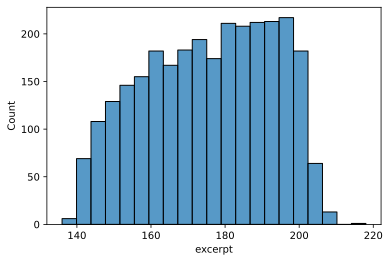

In [13]:
excerpt_lenghts = df_train['excerpt'].apply(lambda x: len(x.split()))
sns.histplot(excerpt_lenghts)

In [14]:
max(excerpt_lenghts)

218

### Observation :- 
    For BERT , Its required to share the maximum words in the text 

In [15]:
class CFG:
    
    max_len = 218
    
    train_batch_size = 8
    valid_batch_size = 16
    
    epochs = 5
    learning_rate = 1e-5
    n_accumulate = 1
    folds = 5
    
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/466k [00:00<?, ?B/s]

# Sampling Strategy - KFOLD

In [16]:
def create_folds(df, n_s=5, n_grp=None):
    df['Fold'] = -1
    
    if n_grp is None:
        skf = KFold(n_splits=n_s)
        target = df.target
    else:
        skf = StratifiedKFold(n_splits=n_s)
        df['grp'] = pd.cut(df.target, n_grp, labels=False)
        target = df.grp
    
    for fold_no, (t, v) in enumerate(skf.split(target, target)):
        df.loc[v, 'Fold'] = fold_no
    return df

In [17]:
df_train = create_folds(df_train, n_s=CFG.folds, n_grp=100)
df_train['Fold'].value_counts()

3    567
1    567
2    567
0    567
4    566
Name: Fold, dtype: int64

## Let See How the Taget is distribured accross folds

In [18]:
def viz_tgt_folds(df):
    fig, axs = plt.subplots(1, 5, sharex=True, sharey=True, figsize=(10,4))
    for i, ax in enumerate(axs):
        ax.hist(df[df.Fold == i]['target'], bins=100, density=True, label=f'Fold-{i}')
        if i == 0:
            ax.set_ylabel('Frequency')
        if i == 2:
            ax.set_xlabel("Target")
        ax.legend(frameon=False, handlelength=0)
    plt.tight_layout()
    plt.show()
    
    return None

In [19]:
viz_tgt_folds(df)

NameError: name 'df' is not defined

### Observation :- 
#### Target distribution accross the folds looks normal and evenly distributed

## Ensuring the distribution of Folds

We can compare any two folds with the **Kolmogorov-Smirnov** test to examine if the folds come from the same distribution. Let's compare all folds with the 1st fold for simplicity. The test results are given below. Indeed, the low KS (~0.0008) and high probability (1.0) values confirm that all folds come from the same distribution.

In [20]:
for fold in np.sort(df.Fold.unique())[1:]:
    print(f'Fold 0 vs {fold}:', ks_2samp(df.loc[df.Fold==0,'target'], df.loc[df.Fold==fold,'target']))

NameError: name 'df' is not defined

### Observation :- 
#### We Can Statisticaly say that target distribution even where as PValue approaching 1 and Statistic is less than zero

<br>
<h1 style = "font-size:60px; font-family:Garamond ; font-weight : normal; background-color: #f6f5f7 ; color : #fe346e; text-align: center; border-radius: 100px 85;">CommonLit Readability<br> BERT Model</h1>
<br>

## Preparing Torch dataset for BERT 

In [21]:
class BERTDset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.text = df['excerpt'].values
        self.target = df['target'].values
        self.max_len = max_len
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.text)
    
    def __getitem__(self, index):
        text = self.text[index]
        inputs = self.tokenizer.encode_plus(
            text,
            None,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=True
        )
        ids = inputs['input_ids']
        mask = inputs['attention_mask']
        token_type_ids = inputs["token_type_ids"]
        
        return {
            'ids': torch.tensor(ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'target': torch.tensor(self.target[index], dtype=torch.float)
        }

## Loss Function

In [22]:
def eval_metrics(outputs, targets):
    return torch.sqrt(nn.MSELoss()(outputs, targets))

In [23]:
class BERTClass(nn.Module):
    def __init__(self):
        super(BERTClass, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(768, 1)
    
    def forward(self, ids, mask, token_type_ids):
        _, output = self.bert(ids, attention_mask = mask, 
                              token_type_ids = token_type_ids, 
                              return_dict=False)
        output = self.dropout(output)
        output = self.fc(output)
        return output

model = BERTClass()
model.to(CFG.device);

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/440M [00:00<?, ?B/s]

<br>
<h1 style = "font-size:60px; font-family:Garamond ; font-weight : normal; background-color: #f6f5f7 ; color : #fe346e; text-align: center; border-radius: 100px 85;">BERT Model - Training & Validation </h1>
<br>

In [24]:
def training(model,optimizer,scheduler,dataloader,device,epoch):
    model.train()
    scaler = amp.GradScaler()
    
    dataset_size = 0
    running_loss = 0.0
    
    bar = tqdm(enumerate(dataloader), total=len(dataloader))
    for step, data in bar:        
        ids = data['ids'].to(device, dtype = torch.long)
        mask = data['mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['target'].to(device, dtype = torch.float)
        
        batch_size = ids.size(0)
        
        with amp.autocast(enabled=True):
            outputs = model(ids, mask, token_type_ids)
            loss = eval_metrics(outputs, targets)
            loss = loss / CFG.n_accumulate
            
        scaler.scale(loss).backward()
        
        if (step + 1) % CFG.n_accumulate == 0:
            scaler.step(optimizer)
            scaler.update()
            
            # zero the parameter gradients
            optimizer.zero_grad()
            
            if scheduler is not None:
                scheduler.step()
                
        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size
        
        epoch_loss = running_loss/dataset_size
        
        bar.set_postfix(Epoch=epoch, Train_Loss=epoch_loss,
                        LR=optimizer.param_groups[0]['lr'])
    gc.collect()
    
    return epoch_loss

In [25]:
def inferance(model,optimizer,scheduler,dataloader,device,epoch):
    
    model.eval()
    
    dataset_size = 0
    running_loss = 0.0
    
    bar = tqdm(enumerate(dataloader), total=len(dataloader))
    for step, data in bar:        
        ids = data['ids'].to(device, dtype = torch.long)
        mask = data['mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['target'].to(device, dtype = torch.float)
        
        batch_size = ids.size(0)
        
        outputs = model(ids, mask, token_type_ids)
        loss = eval_metrics(outputs, targets)
        
        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size
        
        epoch_loss = running_loss/dataset_size
        
        bar.set_postfix(Epoch=epoch, Valid_Loss=epoch_loss,
                        LR=optimizer.param_groups[0]['lr'])   
    gc.collect()
    
    return epoch_loss

In [26]:
@logger.catch
def run(model, optimizer, scheduler, device, num_epochs):    
    start = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = np.inf
    history = defaultdict(list)
    
    for epoch in range(1, num_epochs + 1): 
        gc.collect()
        train_epoch_loss = training(model, optimizer, scheduler, dataloader=train_loader, 
                                           device=CFG.device, epoch=epoch)
        
        valid_epoch_loss = inferance(model, optimizer, scheduler, dataloader=valid_loader, 
                                           device=CFG.device, epoch=epoch)
    
        history['Train Loss'].append(train_epoch_loss)
        history['Valid Loss'].append(valid_epoch_loss)
        
        # deep copy the model
        if valid_epoch_loss <= best_loss:
            print(f"Validation Loss Improved ({best_loss} ---> {valid_epoch_loss})")
            best_loss = valid_epoch_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            PATH = "Loss{:.4f}_epoch{:.0f}.bin".format(best_loss, epoch)
            torch.save(model.state_dict(), PATH)
            print("Model Saved")
    
    print()
    
    end = time.time()
    time_elapsed = end - start
    print('Training complete in {:.0f}h {:.0f}m {:.0f}s'.format(
        time_elapsed // 3600, (time_elapsed % 3600) // 60, (time_elapsed % 3600) % 60))
    print("Best Loss: {:.4f}".format(best_loss))
    
    # load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, history

In [27]:
def prepare_data(df,fold):
    
    df_train = df[df.Fold == fold].reset_index(drop=True)
    df_valid = df[df.Fold == fold].reset_index(drop=True)
    
    train_dataset = BERTDset(df_train, CFG.tokenizer, CFG.max_len)
    valid_dataset = BERTDset(df_valid, CFG.tokenizer, CFG.max_len)

    train_loader = DataLoader(train_dataset, batch_size=CFG.train_batch_size, 
                              num_workers=4, shuffle=True, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=CFG.valid_batch_size, 
                              num_workers=4, shuffle=False, pin_memory=True)
    
    return train_loader, valid_loader

In [28]:
train_loader, valid_loader = prepare_data(df_train,fold=1)

In [29]:
for x in valid_loader:
    print(x)
    break

{'ids': tensor([[  101,  4083,  2055,  ...,     0,     0,     0],
        [  101,  1996,  2430,  ...,     0,     0,     0],
        [  101,  1996,  3011,  ...,     0,     0,     0],
        ...,
        [  101,  1996,  2645,  ...,  3467, 15811,   102],
        [  101,  1037,  9088,  ...,     0,     0,     0],
        [  101,  1037, 10046,  ...,     0,     0,     0]]), 'mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'target': tensor([-0.3866, -0.7550, -0.8229, -1.5340, -0.4512, -0.3611, -0.3512, -0.8493,
        -0.8296, -0.5151, -0.7483, -0.5186, -0.5453, -0.8739, -1.1559, -1.1

In [30]:
# Defining Optimizer with weight decay to params other than bias and layer norms
param_optimizer = list(model.named_parameters())
no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]
optimizer_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], 
     'weight_decay': 0.0001},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], 
     'weight_decay': 0.0}
    ]  

optimizer = AdamW(optimizer_parameters, lr=CFG.learning_rate)

#Defining LR Scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=0, 
    num_training_steps=len(train_loader)*CFG.epochs
)

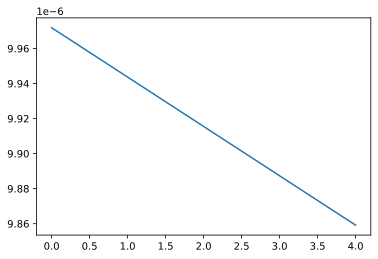

In [31]:
lrs = []
for epoch in range(1, CFG.epochs + 1):
    scheduler.step()
    lrs.append(optimizer.param_groups[0]["lr"])
plt.plot(lrs);

In [32]:
model, history = run(model, optimizer, scheduler, device=CFG.device, num_epochs=CFG.epochs)

100%|██████████| 36/36 [00:04<00:00,  7.31it/s, Epoch=1, LR=7.86e-6, Valid_Loss=0.971]


Validation Loss Improved (inf ---> 0.9706607819444498)
Model Saved


100%|██████████| 36/36 [00:04<00:00,  7.50it/s, Epoch=3, LR=3.86e-6, Valid_Loss=0.968]


Validation Loss Improved (0.9706607819444498 ---> 0.9679288477283726)
Model Saved


100%|██████████| 36/36 [00:04<00:00,  7.24it/s, Epoch=4, LR=1.86e-6, Valid_Loss=0.966]


Validation Loss Improved (0.9679288477283726 ---> 0.9657199403806549)
Model Saved


100%|██████████| 36/36 [00:04<00:00,  7.35it/s, Epoch=5, LR=0, Valid_Loss=0.964]


Validation Loss Improved (0.9657199403806549 ---> 0.9636648710442599)
Model Saved

Training complete in 0h 1m 56s
Best Loss: 0.9637


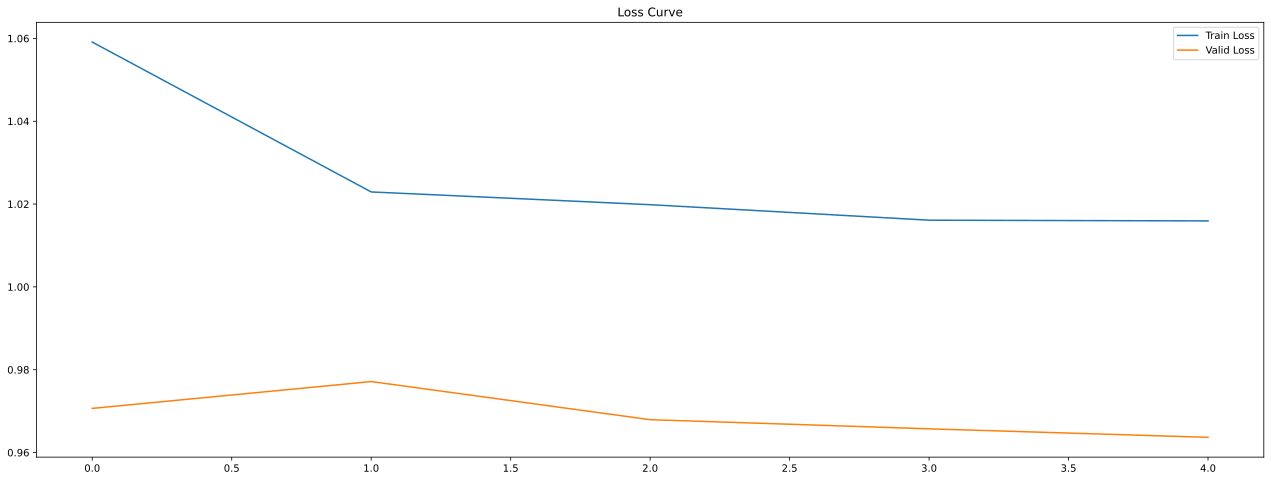

In [33]:
fig = plt.figure(figsize=(22,8))
plt.plot(history['Train Loss'], label='Train Loss')
plt.plot(history['Valid Loss'], label='Valid Loss')
plt.legend()
plt.title('Loss Curve');

### ... In progress 